# Data Understanding

In [30]:
# To understand what data type the data resources are
data_type = df.dtypes
data_type

Unnamed: 0                  int64
Destination Port            int64
Flow Duration               int64
Total Fwd Packets           int64
Total Backward Packets      int64
                           ...   
Idle Mean                 float64
Idle Std                  float64
Idle Max                    int64
Idle Min                    int64
Label                         str
Length: 80, dtype: object

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13  Bwd Packet

# Data Preparation

# 1. Write a python program to load data into pandas Data Frame and display last 50 records.

a) Import Libraries

In [6]:
#code
# Import required libraries for data handling, visualization, and statistical testing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

b) Load Data and Display Last 50 Records

In [7]:
#code
# Read the dataset from CSV file and store it in dataframe df
df = pd.read_csv('ids.csv') 
# Display the last 50 rows of the dataset
df.tail(50) 

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


# 2. Write a Python program to create a separate Data Frame containing only the following columns list for further analysis.
# columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Active Mean', 'Idle Mean', 'Label']

In [9]:
#code
# Select important columns required for data analysis
columns = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
    'Active Mean', 'Idle Mean', 'Label'
] 
# Stores these 16 columns in a new DataFrame called 'df_selected'
df_selected= df[columns].copy()
# Display first 5 rows of selected dataset
df_selected.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN


# 3. Write a Python program to check for NaN (missing values) and remove them from the newly created DataFrame.

In [12]:
# check NaN values
print("\nCount of NaN values in each column")
print("________________________________________")
print("Column Name               Total Count"  )
print("________________________________________\n", df_selected.isnull().sum())

# count total NaN values in the DataFrame
total_nan = df_selected.isna().sum()
print("--------------------------")
print("Total NaN values: ", total_nan.sum())
print("--------------------------")
# remove NaN values
new_df = df_selected.dropna()

#count of nan value after removing missing values
print("\nCount of NaN values in each column after removing NaN values")
print("________________________________________________________")
print("Column Name                 Total Count")
print("________________________________________________________\n", new_df.isna().sum())


Count of NaN values in each column
________________________________________
Column Name               Total Count
________________________________________
 Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64
--------------------------
Total NaN values:  36
--------------------------

Count of NaN values in each column after removing NaN values
________________________________________________________
Column Name                 Total Count
___________________________________________________

# 4. Write a python program to check if duplicated records exist and find their total number.

In [13]:
#Code
# Check for duplicated rows
duplicates = new_df.duplicated()

# Count total duplicates
total_duplicates = duplicates.sum()

if total_duplicates > 0:
    print("Duplicate records exist.")
    print("Total duplicated records:", total_duplicates)
else:
    print("No duplicate records exist.")

Duplicate records exist.
Total duplicated records: 139389


# 5. Write a python program to show total number of columns. Also display name of all columns. 

In [14]:
#Code
print("Total number of columns:", new_df.shape[1])
print("Column names: ")
print(new_df.columns)

Total number of columns: 16
Column names: 
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
       'Active Mean', 'Idle Mean', 'Label'],
      dtype='str')


 # 6. Rename the values in the Label column as follows:
# BENIGN – Normal Traffic
# Infiltration – Attack

In [15]:
#Code
# Show original Label name
print("____________________________________")
print("Original Label name")
print("____________________________________")
print(new_df['Label'].value_counts())

# Rename the values in the Label column
new_df['Label'] = new_df['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})

# Show updated Label values
print("____________________________________")
print("Renamed label")
print("____________________________________")
print(new_df['Label'].value_counts())

____________________________________
Original Label name
____________________________________
Label
BENIGN          288548
Infiltration    199531
Name: count, dtype: int64
____________________________________
Renamed label
____________________________________
Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64


# Data Analysis

# 1. Write a Python program to show summary statistics of sum, mean, standard deviation, skewness, and kurtosis of any 2 chosen numeric variable.

In [16]:
#Code
# Flow Duration statistics
print("Flow Duration")
print("-------------")
print("\nSum: ", new_df['Flow Duration'].sum())
print("\nMean:", new_df['Flow Duration'].mean())
print("\nStandard Deviation:", new_df['Flow Duration'].std())
print("\nSkewness:", new_df['Flow Duration'].skew())
print("\nKurtosis:", new_df['Flow Duration'].kurt())
print("___________________________________________________________________________________________")
print("___________________________________________________________________________________________")

# Packet Length Mean statistics
print("\nPacket Length Mean")
print("--------------------")
print("\nSum:", new_df['Packet Length Mean'].sum())
print("\nMean:", new_df['Packet Length Mean'].mean())
print("\nStandard Deviation:", new_df['Packet Length Mean'].std())
print("\nSkewness:", new_df['Packet Length Mean'].skew())
print("\nKurtosis:", new_df['Packet Length Mean'].kurt())

Flow Duration
-------------

Sum:  4364852868645

Mean: 8942922.905195676

Standard Deviation: 27481820.041125722

Skewness: 3.2508743768773116

Kurtosis: 9.246790962992351
___________________________________________________________________________________________
___________________________________________________________________________________________

Packet Length Mean
--------------------

Sum: 41757628.631677166

Mean: 85.55506102839328

Standard Deviation: 173.87246683073874

Skewness: 4.935765643058977

Kurtosis: 34.61051191591095


# 2. Write a Python program to calculate and show correlation of all numeric variables. Display top 5 correlated feature.

# a) Full Correlation matrix

In [29]:
# code
# Select only numeric columns for correlation analysis
numeric_df = new_df.select_dtypes(include=[np.number])
# Generate correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean
Destination Port,1.000000,-0.145250,-0.025711,-0.024028,0.004815,-0.015581,0.005199,-0.217264,0.063783,0.214177,-0.118523,-0.156795,-0.127719,-0.051505,-0.109348
Flow Duration,-0.145250,1.000000,0.124344,0.100836,0.032044,0.063465,0.114950,0.351037,-0.018884,-0.113359,0.324827,0.465984,0.303080,0.204673,0.653138
Total Fwd Packets,-0.025711,0.124344,1.000000,0.949848,0.333574,0.920007,0.035838,0.210119,-0.002078,-0.020480,0.200438,0.174919,0.190185,0.137132,0.074589
Total Backward Packets,-0.024028,0.100836,0.949848,1.000000,0.146728,0.961480,0.015679,0.200844,-0.002868,-0.020564,0.186629,0.156695,0.177268,0.101969,0.066117
Total Length of Fwd Packets,0.004815,0.032044,0.333574,0.146728,1.000000,0.013944,0.127556,0.016333,0.001838,-0.006509,0.080155,0.054492,0.077949,0.058811,0.013443
Total Length of Bwd Packets,-0.015581,0.063465,0.920007,0.961480,0.013944,1.000000,-0.001047,0.194512,-0.001385,-0.012061,0.176026,0.138066,0.167419,0.078208,0.048474
Fwd Packet Length Mean,0.005199,0.114950,0.035838,0.015679,0.127556,-0.001047,1.000000,0.123866,0.154969,-0.078665,0.612858,0.462664,0.628276,0.068762,0.074170
Bwd Packet Length Mean,-0.217264,0.351037,0.210119,0.200844,0.016333,0.194512,0.123866,1.000000,-0.024280,-0.166846,0.824952,0.876817,0.809420,0.187768,0.236769
Flow Bytes/s,0.063783,-0.018884,-0.002078,-0.002868,0.001838,-0.001385,0.154969,-0.024280,1.000000,0.200319,0.127875,0.069086,0.188463,-0.006707,-0.014174
Flow Packets/s,0.214177,-0.113359,-0.020480,-0.020564,-0.006509,-0.012061,-0.078665,-0.166846,0.200319,1.000000,-0.134655,-0.145674,-0.135588,-0.040319,-0.085080


# b) Top 5 Correlated features

In [18]:
# Code
# correlation matrix
corr = new_df.corr(numeric_only=True)

top_corr = corr.abs().unstack().sort_values(ascending=False)
# remove self correlations
top_corr = top_corr[top_corr != 1]
top_corr = top_corr.drop_duplicates()

print("\nTop 5 Correlated Features")
print("______________________________________________________________________") 
print("Feature 1                    Feature 2                  Correlation")
print("______________________________________________________________________")
print(top_corr.head())


Top 5 Correlated Features
______________________________________________________________________
Feature 1                    Feature 2                  Correlation
______________________________________________________________________
Average Packet Size          Packet Length Mean             0.995068
Total Length of Bwd Packets  Total Backward Packets         0.961480
Total Fwd Packets            Total Backward Packets         0.949848
                             Total Length of Bwd Packets    0.920007
Packet Length Std            Packet Length Mean             0.887792
dtype: float64


# Data Exploration

# 1. Plot a bar chart showing the frequency of each category in the Label column (with values as Normal Traffic and Attack). Determine whether the Label, as the dependent variable, is balanced or not in the dataset. Provide an analysis.

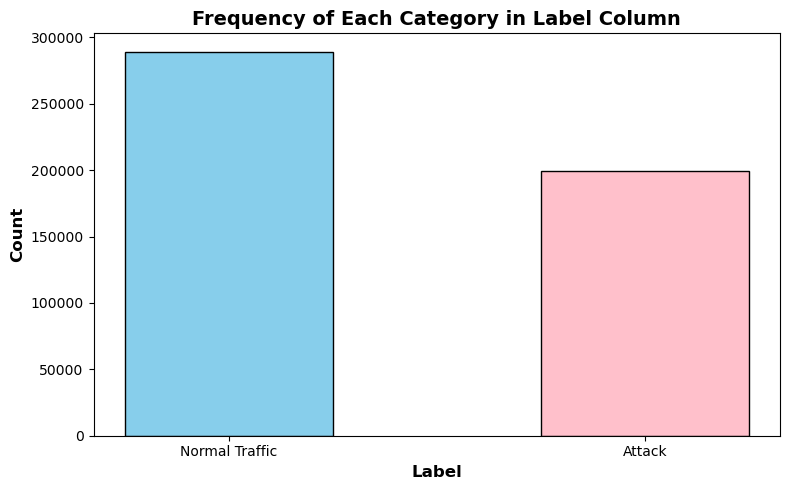

Label,Count
Normal Traffic,288548
Attack,199531


In [19]:
# Code
# Bar chart for label frequency distribution
label_counts = new_df['Label'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color=['skyblue', 'Pink'],
    edgecolor='black',
    width=0.5
)

plt.title('Frequency of Each Category in Label Column', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution table
label_counts.reset_index().rename(
    columns={'index': 'Label', 'count': 'Count'}
).style.hide(axis='index') 

# 2. Determine which category in the Label column (with values as Normal Traffic and Attack) has the highest average Flow Duration and the highest average Packet Length Mean. Visualize these findings with pie chart.

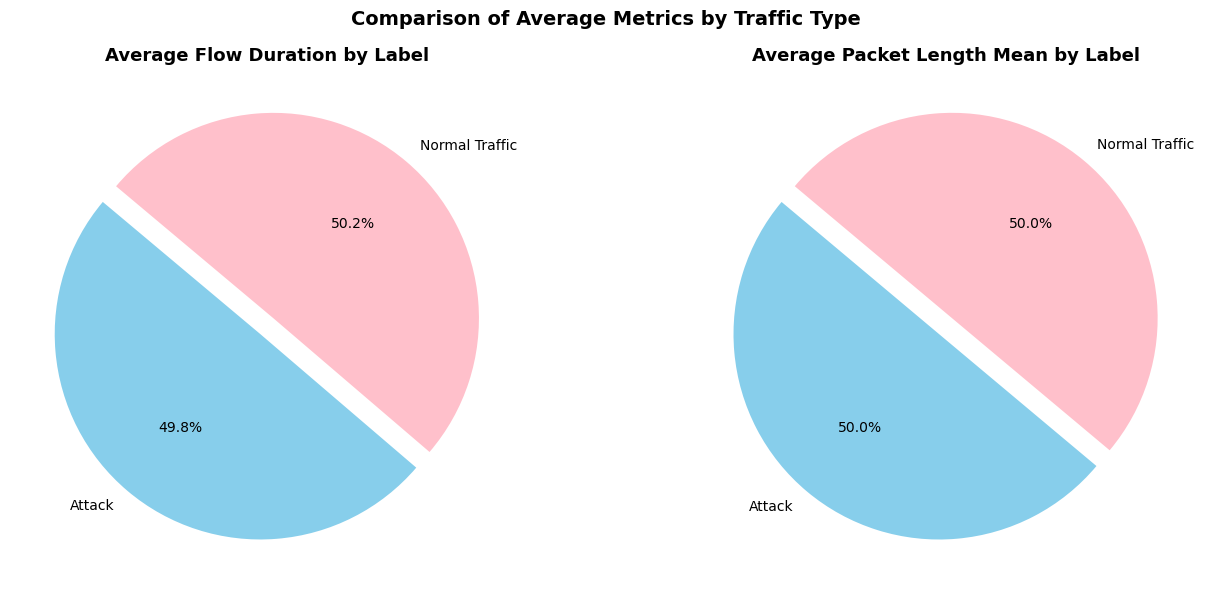

In [20]:
# Code
# Calculate averages
avg_flow_duration = new_df.groupby('Label')['Flow Duration'].mean()
avg_packet_length = new_df.groupby('Label')['Packet Length Mean'].mean()

# Plot pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['skyblue', 'pink']

#First pie chart
axes[0].pie(
    avg_flow_duration.values,
    labels=avg_flow_duration.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=[0.05] * len(avg_flow_duration)
)
axes[0].set_title('Average Flow Duration by Label', fontsize=13, fontweight='bold')

#Second pie chart
axes[1].pie(
    avg_packet_length.values,
    labels=avg_packet_length.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    explode=[0.05] * len(avg_packet_length)
)
axes[1].set_title('Average Packet Length Mean by Label', fontsize=13, fontweight='bold')

plt.suptitle('Comparison of Average Metrics by Traffic Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show() 

# 3. Generate boxplot of 'Fwd Packet Length Mean' grouped by the Label column to visualize the distribution for each attack type and normal traffic. Analyse the differences across these categories.

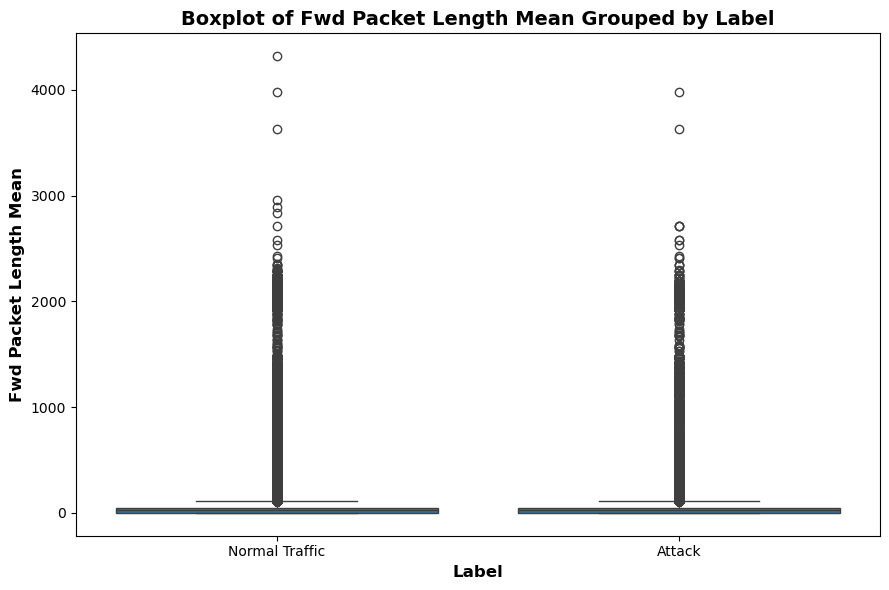

In [21]:
# Code
# Boxplot for Forward Packet Length Mean grouped by label
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=new_df,
    x='Label',
    y='Fwd Packet Length Mean'
)

plt.title('Boxplot of Fwd Packet Length Mean Grouped by Label', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Fwd Packet Length Mean', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. Perform a hypothesis test to determine if there is a significant difference in the mean Flow Duration between Normal Traffic and Attack classes. State your null and alternative hypotheses, choose an appropriate test, perform it, and interpret the results.

In [27]:
#Code
# Null Hypothesis (H0): There is no significant difference in mean Flow Duration between Normal Traffic and Attack classes.

# Alternative Hypothesis (H1): There is a significant difference in mean Flow Duration between Normal Traffic and Attack classes.

# Normal Traffic subset
normal = new_df[new_df['Label'] == 'Normal Traffic']['Flow Duration']

# Traffic attack subset
attack = new_df[new_df['Label'] == 'Attack']['Flow Duration']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(normal, attack)

# Significance level
alpha = 0.05   
print("H0: The Mean Flow Duration of Normal Traffic and Attack are equal")
print("H1: The Mean Flow Duration of Normal Traffic and Attack are different")
print("________________________________________________________________________________________________")
print("\nAlpha Value:", alpha)
print("T-statistic:", t_stat)
print("P-value:", p_value)
print("________________________________________________________________________________________________")
# Interpretation
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: There is a significant difference in mean Flow Duration ehich supports H1.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: There is no significant difference in mean Flow Duration which holds H0.") 

H0: The Mean Flow Duration of Normal Traffic and Attack are equal
H1: The Mean Flow Duration of Normal Traffic and Attack are different
________________________________________________________________________________________________

Alpha Value: 0.05
T-statistic: 0.7161327588416807
P-value: 0.4739097203854357
________________________________________________________________________________________________

Decision: Fail to Reject H0
Conclusion: There is no significant difference in mean Flow Duration which holds H0.
